In [13]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import timm
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from sklearn.metrics import confusion_matrix, classification_report

import time
from tqdm import tqdm
from IPython.display import clear_output

In [ ]:
# 2. Device Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# 3. Dataset Paths

train_dir = "../dataset/RiceLeafsDisease/train"
val_dir = "../dataset/RiceLeafsDisease/validation"

In [ ]:
# 4. Data Transformations

# Training Transform (with augmentation)

train_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(20),
    
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    
    transforms.ToTensor(),
    
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
# 5. Validation Transform (no augmentation)

val_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
# 6. Load Dataset

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=val_transform
)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


In [ ]:
# 7. Optimized DataLoaders
batch_size = 8  

# Optimized DataLoader settings
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print(f"Batch size: {batch_size}, Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Batch size: 8, Train batches: 263, Val batches: 66


In [ ]:
# 8. Load Pretrained ResNet50 with Optimizations

# Load ResNet50
resnet_model = models.resnet50(pretrained=True)

# FREEZE all layers first
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace and unfreeze the classifier
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, len(class_names))

# Unfreeze the final few layers for better accuracy (optional)
for param in resnet_model.layer4.parameters():  # Unfreeze last residual block
    param.requires_grad = True
    
# Always unfreeze the new classifier
for param in resnet_model.fc.parameters():
    param.requires_grad = True

# Move to GPU
resnet_model = resnet_model.to(device)

# Count trainable parameters
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet_model.parameters())
print(f"ResNet50 - Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"Model size: {total_params/1e6:.1f}M parameters")

ResNet50 - Trainable params: 14,977,030 / 23,520,326 (63.7%)
Model size: 23.5M parameters


In [ ]:
# 9. Loss Function & Optimizer
criterion_resnet = nn.CrossEntropyLoss()

# Only optimize trainable parameters
optimizer_resnet = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=0.001  # Higher LR for fine-tuning
)

# Add learning rate scheduler (FIXED: removed verbose parameter)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet, 
    mode='min', 
    patience=3, 
    factor=0.5
    # verbose parameter removed - it's not supported in newer PyTorch
)

# Add mixed precision scaler
scaler_resnet = torch.amp.GradScaler('cuda')

# Optional: Print initial LR to verify
print(f"Initial learning rate: {optimizer_resnet.param_groups[0]['lr']}")

Initial learning rate: 0.001


In [ ]:
# 10. Optimized Training Function for ResNet50
from tqdm import tqdm

def train_epoch_resnet(model, loader, optimizer, criterion, scaler, epoch_num):
    model.train()
    total_loss = 0
    correct = 0
    batch_times = []
    
    progress_bar = tqdm(loader, desc=f'ResNet Epoch {epoch_num} Training')
    for batch_idx, (images, labels) in enumerate(progress_bar):
        batch_start = time.time()
        
        # Move to GPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # Backward pass with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Statistics
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        
        # Update progress bar
        batch_time = time.time() - batch_start
        batch_times.append(batch_time)
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'time': f'{batch_time:.2f}s'
        })
        
        # Clear cache occasionally
        if batch_idx % 30 == 0:  # More frequent for ResNet (larger model)
            torch.cuda.empty_cache()
    
    accuracy = correct / len(loader.dataset)
    avg_time = sum(batch_times) / len(batch_times)
    return total_loss/len(loader), accuracy

In [ ]:
# 11. Optimized Validation Function
def validate_epoch_resnet(model, loader, criterion, epoch_num):
    model.eval()
    total_loss = 0
    correct = 0
    
    with torch.no_grad():
        progress_bar = tqdm(loader, desc=f'ResNet Epoch {epoch_num} Validation')
        for images, labels in progress_bar:
            # Move to GPU
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass (no mixed precision needed)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    accuracy = correct / len(loader.dataset)
    return total_loss/len(loader), accuracy

In [ ]:
# 12. Optimized Training Loop with Timing

epochs = 20
resnet_train_losses = []
resnet_val_losses = []
resnet_train_acc = []
resnet_val_acc = []
prev_lr = None  # Track LR changes

total_start_time = time.time()

for epoch in range(epochs):
    epoch_start = time.time()
    
    # Train
    train_loss, train_accuracy = train_epoch_resnet(
        resnet_model, train_loader, optimizer_resnet, 
        criterion_resnet, scaler_resnet, epoch+1
    )
    
    # Validate
    val_loss, val_accuracy = validate_epoch_resnet(
        resnet_model, val_loader, criterion_resnet, epoch+1
    )
    
    # Store metrics
    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)
    resnet_train_acc.append(train_accuracy)
    resnet_val_acc.append(val_accuracy)
    
    # Learning rate scheduling (using validation loss)
    scheduler_resnet.step(val_loss)
    
    # Check if LR changed
    current_lr = optimizer_resnet.param_groups[0]['lr']
    if prev_lr is not None and prev_lr != current_lr:
        print(f"\n⚠️ Learning rate reduced from {prev_lr:.6f} to {current_lr:.6f}")
    prev_lr = current_lr
    
    epoch_time = time.time() - epoch_start
    total_time_so_far = time.time() - total_start_time
    
    # Calculate estimated time remaining
    avg_epoch_time = total_time_so_far / (epoch + 1)
    remaining_epochs = epochs - (epoch + 1)
    estimated_remaining = avg_epoch_time * remaining_epochs
    
    # Clear output for clean display (but keep first few epochs visible)
    if epoch > 0:  # Don't clear on first epoch
        clear_output(wait=True)
    
    print("="*80)
    print(f"🔷 ResNet50 - Epoch {epoch+1}/{epochs} - Time: {epoch_time/60:.2f} minutes")
    print("="*80)
    print(f"📊 TRAINING   - Loss: {train_loss:.4f} | Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"📊 VALIDATION - Loss: {val_loss:.4f} | Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
    print(f"⚙️ Learning Rate: {current_lr:.6f}")
    print("-"*80)
    print(f"⏱️  Total time elapsed: {total_time_so_far/60:.2f} minutes")
    print(f"⏱️  Estimated time remaining: {estimated_remaining/60:.2f} minutes")
    print(f"⏱️  Estimated total time: {(total_time_so_far + estimated_remaining)/60:.2f} minutes")
    print("="*80)
    
    # Early stopping check (optional)
    if val_accuracy > 0.96:  # If 96% accuracy achieved
        print(f"\n🎯 Target accuracy reached! Stopping early at epoch {epoch+1}")
        break

print(f"\n✅ ResNet50 training completed in {total_time_so_far/60:.2f} minutes!")

# Print final summary
print("\n" + "="*80)
print("📈 FINAL RESULTS SUMMARY")
print("="*80)
print(f"Best Validation Accuracy: {max(resnet_val_acc)*100:.2f}% (Epoch {resnet_val_acc.index(max(resnet_val_acc))+1})")
print(f"Final Validation Accuracy: {resnet_val_acc[-1]*100:.2f}%")
print(f"Best Validation Loss: {min(resnet_val_losses):.4f} (Epoch {resnet_val_losses.index(min(resnet_val_losses))+1})")
print(f"Final Validation Loss: {resnet_val_losses[-1]:.4f}")
print(f"Total Training Time: {total_time_so_far/60:.2f} minutes")
print("="*80)

🔷 ResNet50 - Epoch 6/20 - Time: 7.58 minutes
📊 TRAINING   - Loss: 0.1749 | Accuracy: 0.9457 (94.57%)
📊 VALIDATION - Loss: 0.0959 | Accuracy: 0.9640 (96.40%)
⚙️ Learning Rate: 0.001000
--------------------------------------------------------------------------------
⏱️  Total time elapsed: 43.58 minutes
⏱️  Estimated time remaining: 101.68 minutes
⏱️  Estimated total time: 145.26 minutes

🎯 Target accuracy reached! Stopping early at epoch 6

✅ ResNet50 training completed in 43.58 minutes!

📈 FINAL RESULTS SUMMARY
Best Validation Accuracy: 96.40% (Epoch 6)
Final Validation Accuracy: 96.40%
Best Validation Loss: 0.0959 (Epoch 6)
Final Validation Loss: 0.0959
Total Training Time: 43.58 minutes


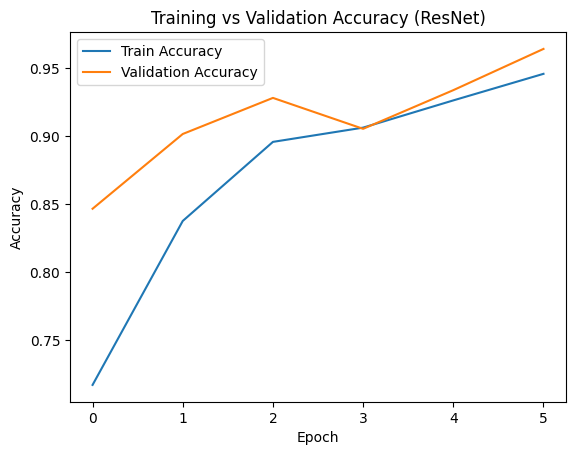

In [ ]:
# 13. Accuracy Graph

plt.plot(resnet_train_acc, label="Train Accuracy")
plt.plot(resnet_val_acc, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy (ResNet)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

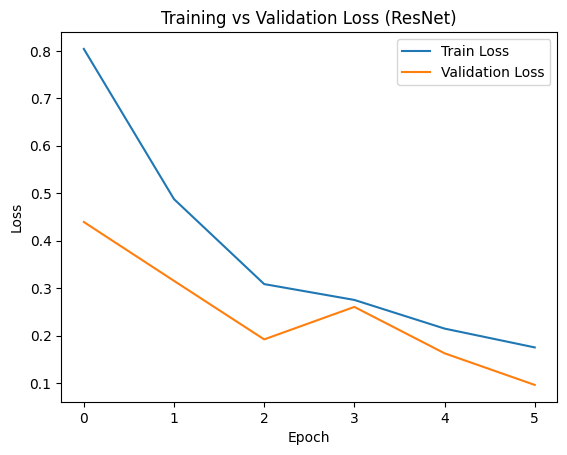

In [ ]:
# 14. Loss Graph

plt.plot(resnet_train_losses, label="Train Loss")
plt.plot(resnet_val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss (ResNet)")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# 15. Model Evaluation

resnet_model.eval()

all_preds_resnet = []
all_labels_resnet = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = resnet_model(images)

        _, preds = torch.max(outputs,1)

        all_preds_resnet.extend(preds.cpu().numpy())
        all_labels_resnet.extend(labels.numpy())

In [ ]:
# 16. Classification Report

print(classification_report(
    all_labels_resnet,
    all_preds_resnet,
    target_names=class_names
))

                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      1.00      1.00        88
           brown_spot       0.95      0.89      0.92        88
              healthy       0.97      0.99      0.98        88
           leaf_blast       0.88      0.95      0.92        88
           leaf_scald       0.99      0.99      0.99        88
    narrow_brown_spot       1.00      0.97      0.98        88

             accuracy                           0.96       528
            macro avg       0.97      0.96      0.96       528
         weighted avg       0.97      0.96      0.96       528



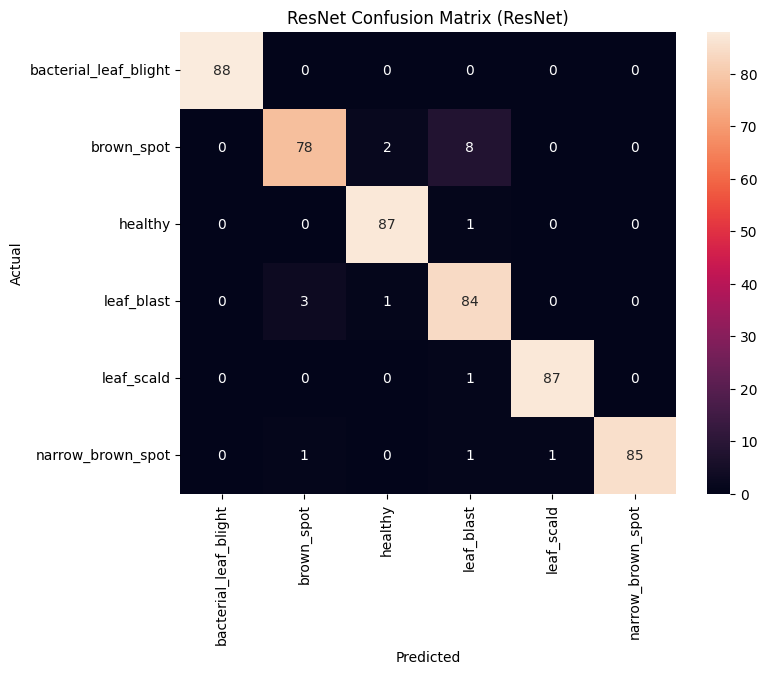

In [ ]:
# 17. Confusion Matrix

cm_resnet = confusion_matrix(all_labels_resnet, all_preds_resnet)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ResNet Confusion Matrix (ResNet)")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# 18. Save ResNet50 Model
torch.save(
    resnet_model.state_dict(),  # Fixed: was saving wrong model
    "resnet50_paddy_model.pth"
)

print("ResNet50 model saved successfully!")

# Also save training history for comparison
with open('resnet50_training_history.pkl', 'wb') as f:
    pickle.dump({
        'train_loss': resnet_train_losses,
        'val_loss': resnet_val_losses,
        'train_acc': resnet_train_acc,
        'val_acc': resnet_val_acc
    }, f)

print("ResNet50 results saved!")

ResNet50 model saved successfully!
ResNet50 results saved!


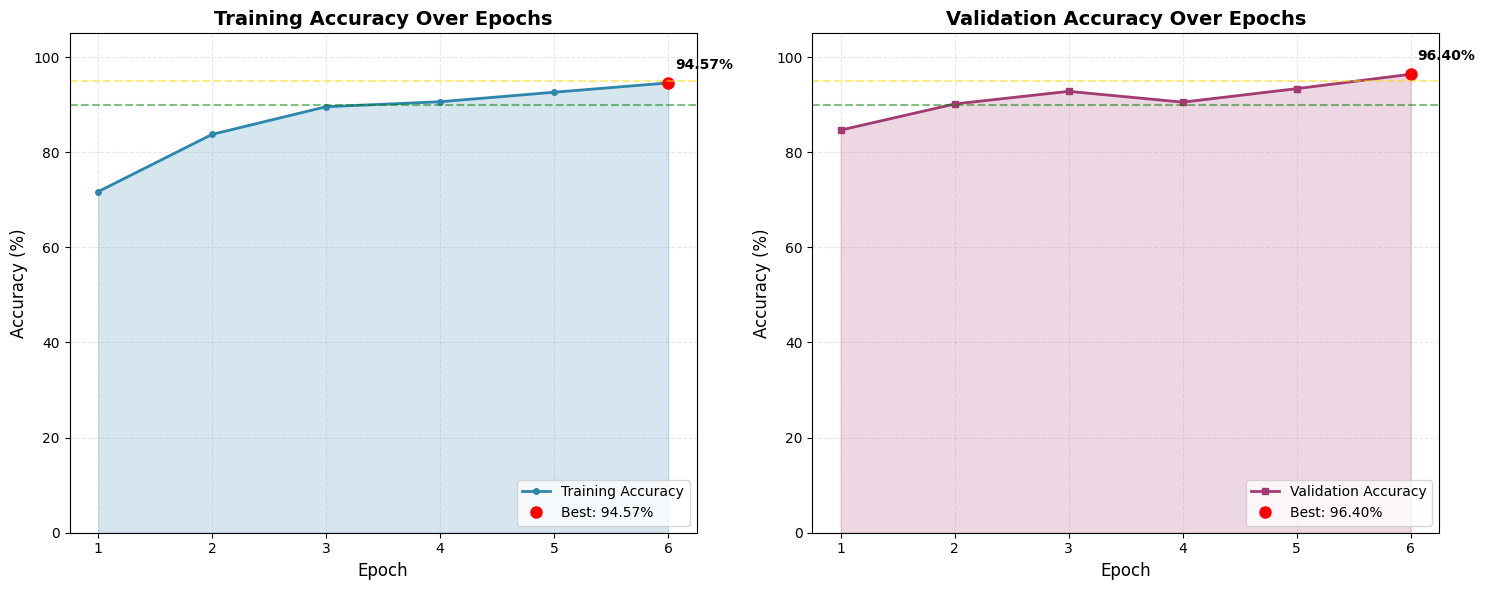


📊 ACCURACY STATISTICS

📈 TRAINING ACCURACY:
   • Initial (Epoch 1): 71.71%
   • Final (Epoch 6): 94.57%
   • Best: 94.57% (Epoch 6)
   • Average: 87.14%
   • Improvement: 22.86%

📉 VALIDATION ACCURACY:
   • Initial (Epoch 1): 84.66%
   • Final (Epoch 6): 96.40%
   • Best: 96.40% (Epoch 6)
   • Average: 91.32%
   • Improvement: 11.74%

🔍 OVERFITTING CHECK:
   ✅ Good generalization! (Gap: -1.83%)
   💡 Model is learning well


In [ ]:
# 19. Plot Training vs Validation Accuracy Separately

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Colors
train_color = '#2E86AB'
val_color = '#A23B72'

# ===== LEFT PLOT: Training Accuracy Only =====
axes[0].plot(range(1, len(resnet_train_acc)+1), 
             [acc*100 for acc in resnet_train_acc], 
             marker='o', markersize=4, linewidth=2, color=train_color, label='Training Accuracy')
axes[0].fill_between(range(1, len(resnet_train_acc)+1), 
                      [acc*100 for acc in resnet_train_acc], 
                      alpha=0.2, color=train_color)

# Add best training accuracy annotation
best_train_epoch = np.argmax(resnet_train_acc) + 1
best_train_acc = max(resnet_train_acc) * 100
axes[0].plot(best_train_epoch, best_train_acc, 'ro', markersize=8, label=f'Best: {best_train_acc:.2f}%')
axes[0].annotate(f'{best_train_acc:.2f}%', 
                 xy=(best_train_epoch, best_train_acc), 
                 xytext=(5, 10), textcoords='offset points', fontsize=10, fontweight='bold')

axes[0].set_title('Training Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim([0, 105])
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend(loc='lower right')
axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
axes[0].axhline(y=95, color='gold', linestyle='--', alpha=0.5, label='95% threshold')

# ===== RIGHT PLOT: Validation Accuracy Only =====
axes[1].plot(range(1, len(resnet_val_acc)+1), 
             [acc*100 for acc in resnet_val_acc], 
             marker='s', markersize=4, linewidth=2, color=val_color, label='Validation Accuracy')
axes[1].fill_between(range(1, len(resnet_val_acc)+1), 
                      [acc*100 for acc in resnet_val_acc], 
                      alpha=0.2, color=val_color)

# Add best validation accuracy annotation
best_val_epoch = np.argmax(resnet_val_acc) + 1
best_val_acc = max(resnet_val_acc) * 100
axes[1].plot(best_val_epoch, best_val_acc, 'ro', markersize=8, label=f'Best: {best_val_acc:.2f}%')
axes[1].annotate(f'{best_val_acc:.2f}%', 
                 xy=(best_val_epoch, best_val_acc), 
                 xytext=(5, 10), textcoords='offset points', fontsize=10, fontweight='bold')

axes[1].set_title('Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_ylim([0, 105])
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(loc='lower right')
axes[1].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
axes[1].axhline(y=95, color='gold', linestyle='--', alpha=0.5, label='95% threshold')

plt.tight_layout()
plt.show()

# ===== PRINT DETAILED STATISTICS =====
print("\n" + "="*60)
print("📊 ACCURACY STATISTICS")
print("="*60)

print(f"\n📈 TRAINING ACCURACY:")
print(f"   • Initial (Epoch 1): {resnet_train_acc[0]*100:.2f}%")
print(f"   • Final (Epoch {len(resnet_train_acc)}): {resnet_train_acc[-1]*100:.2f}%")
print(f"   • Best: {best_train_acc:.2f}% (Epoch {best_train_epoch})")
print(f"   • Average: {np.mean(resnet_train_acc)*100:.2f}%")
print(f"   • Improvement: {resnet_train_acc[-1]*100 - resnet_train_acc[0]*100:.2f}%")

print(f"\n📉 VALIDATION ACCURACY:")
print(f"   • Initial (Epoch 1): {resnet_val_acc[0]*100:.2f}%")
print(f"   • Final (Epoch {len(resnet_val_acc)}): {resnet_val_acc[-1]*100:.2f}%")
print(f"   • Best: {best_val_acc:.2f}% (Epoch {best_val_epoch})")
print(f"   • Average: {np.mean(resnet_val_acc)*100:.2f}%")
print(f"   • Improvement: {resnet_val_acc[-1]*100 - resnet_val_acc[0]*100:.2f}%")

# Check for overfitting
print(f"\n🔍 OVERFITTING CHECK:")
train_final = resnet_train_acc[-1]*100
val_final = resnet_val_acc[-1]*100
gap = train_final - val_final

if gap > 5:
    print(f"   ⚠️  Possible overfitting! (Gap: {gap:.2f}%)")
    print(f"   💡 Try adding dropout or reducing model complexity")
elif gap > 2:
    print(f"   📊 Mild overfitting (Gap: {gap:.2f}%)")
    print(f"   💡 Consider early stopping or regularization")
else:
    print(f"   ✅ Good generalization! (Gap: {gap:.2f}%)")
    print(f"   💡 Model is learning well")

print("="*60)

Loaded EfficientNet results successfully!


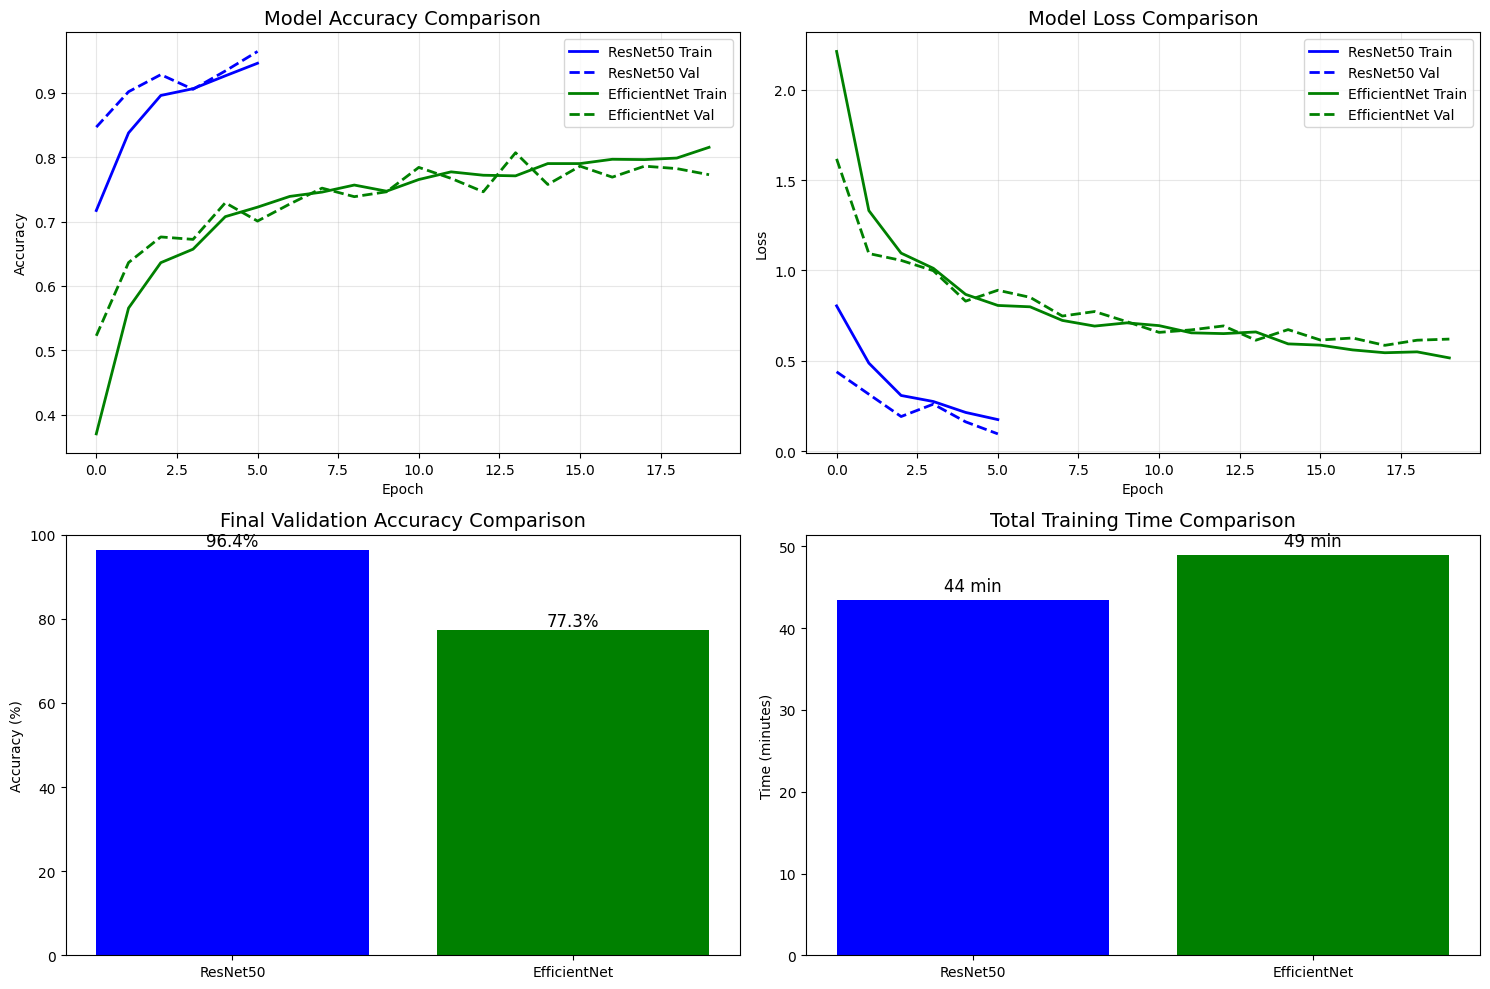


MODEL COMPARISON SUMMARY
Model                Final Val Acc   Best Val Acc    Time (min)     
------------------------------------------------------------
ResNet50             96.40% 96.40% 43.5           
EfficientNet-B0      77.27% 80.68% 49             

📊 RECOMMENDATION:
✅ ResNet50 performs better in accuracy


In [34]:
# 20. Compare with EfficientNet (Load saved results)

# Load EfficientNet results
efficientnet_results = None
if os.path.exists('efficientnet_results.pkl'):
    with open('efficientnet_results.pkl', 'rb') as f:
        efficientnet_results = pickle.load(f)
    print("Loaded EfficientNet results successfully!")
else:
    print("No EfficientNet results found. Run EfficientNet training first or save only ResNet results.")

# Plot comparison
plt.figure(figsize=(15, 10))

# Accuracy comparison
plt.subplot(2, 2, 1)
plt.plot(resnet_train_acc, label='ResNet50 Train', linewidth=2, color='blue')
plt.plot(resnet_val_acc, label='ResNet50 Val', linewidth=2, linestyle='--', color='blue')

if efficientnet_results:
    plt.plot(efficientnet_results['train_acc'], label='EfficientNet Train', linewidth=2, color='green')
    plt.plot(efficientnet_results['val_acc'], label='EfficientNet Val', linewidth=2, linestyle='--', color='green')

plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss comparison
plt.subplot(2, 2, 2)
plt.plot(resnet_train_losses, label='ResNet50 Train', linewidth=2, color='blue')
plt.plot(resnet_val_losses, label='ResNet50 Val', linewidth=2, linestyle='--', color='blue')

if efficientnet_results:
    plt.plot(efficientnet_results['train_loss'], label='EfficientNet Train', linewidth=2, color='green')
    plt.plot(efficientnet_results['val_loss'], label='EfficientNet Val', linewidth=2, linestyle='--', color='green')

plt.title('Model Loss Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Final Accuracy Bar Chart
plt.subplot(2, 2, 3)
models = ['ResNet50']
accuracies = [resnet_val_acc[-1] * 100]  # Final validation accuracy

if efficientnet_results:
    models.append('EfficientNet')
    accuracies.append(efficientnet_results['val_acc'][-1] * 100)

colors = ['blue', 'green']
bars = plt.bar(models, accuracies, color=colors[:len(models)])
plt.title('Final Validation Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim([0, 100])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}%', ha='center', fontsize=12)

# Training Time Comparison
plt.subplot(2, 2, 4)

resnet_time = 43.5
efficientnet_time = 49

times = [resnet_time]
model_names = ['ResNet50']

if efficientnet_results:
    times.append(efficientnet_time)
    model_names.append('EfficientNet')

bars = plt.bar(model_names, times, color=colors[:len(model_names)])
plt.title('Total Training Time Comparison', fontsize=14)
plt.ylabel('Time (minutes)')

# Add value labels on bars
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{t:.0f} min', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<20} {'Final Val Acc':<15} {'Best Val Acc':<15} {'Time (min)':<15}")
print("-"*60)
print(f"{'ResNet50':<20} {resnet_val_acc[-1]*100:.2f}% {max(resnet_val_acc)*100:.2f}% {resnet_time:<15}")

if efficientnet_results:
    print(f"{'EfficientNet-B0':<20} {efficientnet_results['val_acc'][-1]*100:.2f}% "
          f"{max(efficientnet_results['val_acc'])*100:.2f}% {efficientnet_time:<15}")
print("="*60)

# Recommendation
print("\n📊 RECOMMENDATION:")
if efficientnet_results:
    if resnet_val_acc[-1] > efficientnet_results['val_acc'][-1]:
        print("✅ ResNet50 performs better in accuracy")
    else:
        print("✅ EfficientNet-B0 performs better in accuracy")
    
    if resnet_time > efficientnet_time * 1.5:
        print("⚠️ ResNet50 takes significantly longer to train")
else:
    print("Run both models to get comparison")